In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso, Ridge
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
df = pd.read_csv(r"C:\Users\Dell\OneDrive - Sahana System Limited\Desktop\india-economy-etl\data\india_economy_clean.csv")

X = df[['inflation_rate', 'fdi_inflow', 'year']]
y = df['gdp_growth_rate']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Data prepared successfully!")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Features used: {list(X.columns)}")

Data prepared successfully!
Training samples: 44
Testing samples: 11
Features used: ['inflation_rate', 'fdi_inflow', 'year']


In [4]:
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Machine': SVR(kernel='rbf', C=1.0),
    'K-Nearest Neighbours': KNeighborsRegressor(n_neighbors=5),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Lasso Regression': Lasso(alpha=0.1),
    'Ridge Regression': Ridge(alpha=1.0)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
    results[name] = {
        'R2 Score': round(r2, 4),
        'RMSE': round(rmse, 4),
        'CV Mean': round(cv_scores.mean(), 4),
        'CV Std': round(cv_scores.std(), 4)
    }
    print(f"{name}:")
    print(f"  R2 Score: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  Cross Validation Mean: {cv_scores.mean():.4f}")
    print()

results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df)

Random Forest:
  R2 Score: -1.6754
  RMSE: 2.8902
  Cross Validation Mean: -1.0122

Gradient Boosting:
  R2 Score: -1.4598
  RMSE: 2.7712
  Cross Validation Mean: -1.3888

Support Vector Machine:
  R2 Score: -0.8028
  RMSE: 2.3725
  Cross Validation Mean: -0.3884

K-Nearest Neighbours:
  R2 Score: -2.0217
  RMSE: 3.0715
  Cross Validation Mean: -0.5684

Decision Tree:
  R2 Score: -3.3062
  RMSE: 3.6667
  Cross Validation Mean: -2.7948

Lasso Regression:
  R2 Score: -0.7352
  RMSE: 2.3276
  Cross Validation Mean: -0.5222

Ridge Regression:
  R2 Score: -0.7642
  RMSE: 2.3469
  Cross Validation Mean: -0.7357


Model Comparison:
                        R2 Score    RMSE  CV Mean  CV Std
Random Forest            -1.6754  2.8902  -1.0122  1.4734
Gradient Boosting        -1.4598  2.7712  -1.3888  2.1912
Support Vector Machine   -0.8028  2.3725  -0.3884  0.2968
K-Nearest Neighbours     -2.0217  3.0715  -0.5684  0.6748
Decision Tree            -3.3062  3.6667  -2.7948  4.2316
Lasso Regression   

In [5]:
df_ml = df.copy()

df_ml['gdp_lag1'] = df_ml['gdp_growth_rate'].shift(1)
df_ml['gdp_lag2'] = df_ml['gdp_growth_rate'].shift(2)
df_ml['inflation_lag1'] = df_ml['inflation_rate'].shift(1)
df_ml['fdi_lag1'] = df_ml['fdi_inflow'].shift(1)
df_ml['gdp_rolling_mean3'] = df_ml['gdp_growth_rate'].rolling(3).mean().shift(1)

df_ml = df_ml.dropna()

X2 = df_ml[['inflation_rate', 'fdi_inflow', 'year',
            'gdp_lag1', 'gdp_lag2', 'inflation_lag1',
            'fdi_lag1', 'gdp_rolling_mean3']]
y2 = df_ml['gdp_growth_rate']

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2_scaled, y2, test_size=0.2, random_state=42
)

print("Enhanced features prepared!")
print(f"Features: {list(X2.columns)}")
print(f"Training samples: {len(X_train2)}")
print(f"Testing samples: {len(X_test2)}")

Enhanced features prepared!
Features: ['inflation_rate', 'fdi_inflow', 'year', 'gdp_lag1', 'gdp_lag2', 'inflation_lag1', 'fdi_lag1', 'gdp_rolling_mean3']
Training samples: 41
Testing samples: 11


In [6]:
results2 = {}

for name, model in models.items():
    model.fit(X_train2, y_train2)
    y_pred2 = model.predict(X_test2)
    r2 = r2_score(y_test2, y_pred2)
    rmse = np.sqrt(mean_squared_error(y_test2, y_pred2))
    cv_scores = cross_val_score(model, X2_scaled, y2, cv=5, scoring='r2')
    results2[name] = {
        'R2 Score': round(r2, 4),
        'RMSE': round(rmse, 4),
        'CV Mean': round(cv_scores.mean(), 4),
        'CV Std': round(cv_scores.std(), 4)
    }
    print(f"{name}:")
    print(f"  R2 Score: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  Cross Validation Mean: {cv_scores.mean():.4f}")
    print()

results2_df = pd.DataFrame(results2).T
print("\nImproved Model Comparison:")
print(results2_df)

Random Forest:
  R2 Score: -0.0639
  RMSE: 4.0661
  Cross Validation Mean: -0.3172

Gradient Boosting:
  R2 Score: -0.5270
  RMSE: 4.8714
  Cross Validation Mean: -0.1111

Support Vector Machine:
  R2 Score: -0.1452
  RMSE: 4.2185
  Cross Validation Mean: -0.2263

K-Nearest Neighbours:
  R2 Score: -0.0218
  RMSE: 3.9848
  Cross Validation Mean: -0.6546

Decision Tree:
  R2 Score: -1.9153
  RMSE: 6.7308
  Cross Validation Mean: -2.6053

Lasso Regression:
  R2 Score: -0.1832
  RMSE: 4.2880
  Cross Validation Mean: -0.5781

Ridge Regression:
  R2 Score: -0.1698
  RMSE: 4.2636
  Cross Validation Mean: -0.9410


Improved Model Comparison:
                        R2 Score    RMSE  CV Mean  CV Std
Random Forest            -0.0639  4.0661  -0.3172  0.6260
Gradient Boosting        -0.5270  4.8714  -0.1111  0.4099
Support Vector Machine   -0.1452  4.2185  -0.2263  0.1406
K-Nearest Neighbours     -0.0218  3.9848  -0.6546  0.4757
Decision Tree            -1.9153  6.7308  -2.6053  4.0254
Lasso Regr

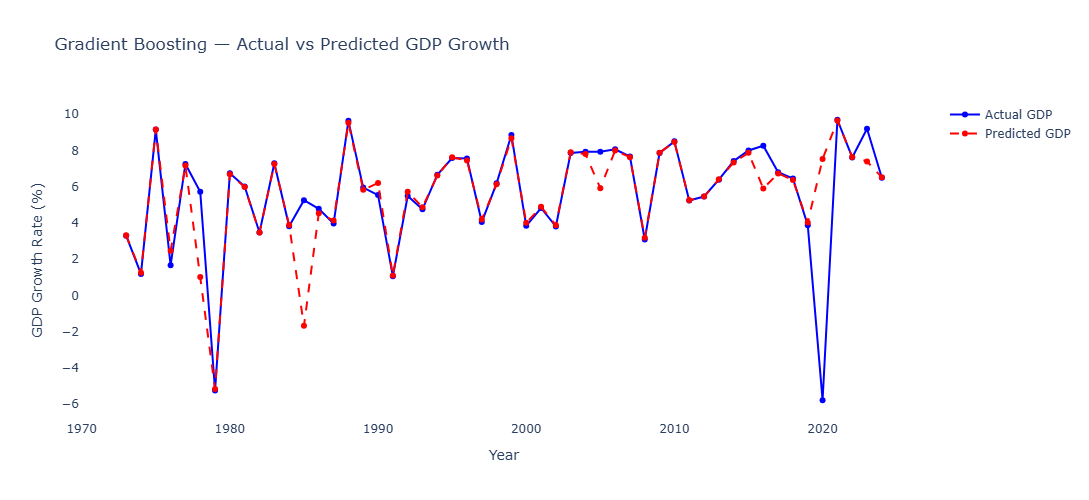

In [7]:
best_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train2, y_train2)
y_pred_best = best_model.predict(X2_scaled)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_ml['year'],
    y=y2.values,
    mode='lines+markers',
    name='Actual GDP',
    line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=df_ml['year'],
    y=y_pred_best,
    mode='lines+markers',
    name='Predicted GDP',
    line=dict(color='red', dash='dash')
))

fig.update_layout(
    title='Gradient Boosting — Actual vs Predicted GDP Growth',
    xaxis_title='Year',
    yaxis_title='GDP Growth Rate (%)',
    plot_bgcolor='white',
    hovermode='x unified',
    width=900,
    height=500
)

fig.show()